# Discovering Music Taste Patterns with Last.fm Scrobbles

In this notebook I explored how unsupervised and supervised models can describe and predict music taste using the `lastfm-user-artist-scrobbles` dataset.

**Data preparation and representation**

- Loaded multi‑user scrobble counts (`user_id`, `artist_id`, `scrobbles`) and artist metadata (`artist_id`, `artist_name`).
- Focused on the 500 most‑listened artists and built an **artists × users** matrix (rows = artists, columns = users, values = play counts).
- This matrix became the central object for all later modeling.

**Latent “taste” features and artist similarity**

- Trained a pipeline `MaxAbsScaler → NMF(n_components=20) → Normalizer` on the artist–user matrix to learn **20 non‑negative latent taste components** and normalize each artist vector.
- Inspected components by listing **top‑loading artists per component** and interpreted them as human “taste directions” (e.g. modern pop, classical, metal, K‑pop, etc.).
- Built a **cosine‑similarity search** in this space and wrapped it into a function `recommend_similar(artist_name, n)` that returns the most similar artists to a seed (e.g. “Radiohead”).

**Clustering artists into taste scenes**

- Ran **KMeans (k=10)** on the normalized NMF features to group artists into taste clusters.
- Examined each cluster by listing member artists; clusters aligned well with intuitive scenes:
  - classical & standards, rock/metal, K‑pop, anime/J‑rock/game OST, indie/alt rock, modern pop, etc.
- This showed that **unsupervised structure from listening behavior** recovers meaningful genre/scene groupings without any labels.

**User activity and behavior exploration**

- Computed **total scrobbles per user** and examined their distribution on a log scale.
- Defined four **activity groups** by quantiles of total scrobbles:
  - “reluctant” (bottom 25%), “below_avg” (25–50%), “active” (50–90%), “power” (top 10%).
- For each user, computed their **cluster‑share vector**: what fraction of their listening goes to each of the 10 artist clusters.
- Measured **max_cluster_share** (dominant taste concentration) per user and compared across activity groups:
  - All groups were fairly concentrated (typical max share ≈ 0.58–0.62); reluctant and power users were slightly more focused than the middle groups.
- Built a **group vs cluster heatmap** of average cluster shares:
  - All groups leaned most to the big pop cluster (cluster 9), with power users especially strong there; otherwise, taste mixes were surprisingly similar across activity levels.

**Model 1 – Can taste mix predict activity level?**

- Framed a **multiclass classification** problem:
  - Features: user cluster‑shares (10‑dim vector).
  - Target: activity group (`reluctant`, `below_avg`, `active`, `power`).
- Trained a multinomial logistic regression; test accuracy ≈ **0.41**, only slightly above a majority‑class baseline.
- Conclusion: **activity level is not well predicted by coarse taste mix** in this dataset; users with similar taste profiles can be light or heavy listeners.

**Model 2 – Predict dominant taste cluster from early listening**

- Defined each user’s **dominant cluster** as the cluster with highest share over their full listening history (top‑artist subset).
- Simulated an **“early patch”** by taking a binomial 10% sample of scrobbles per (user, artist, cluster) and recomputing early cluster shares.
- Built features from **early cluster_share_early** (10‑dim vector) and target from the **true dominant cluster**.
- Trained logistic regression:
  - Test accuracy ≈ **0.95**, macro recall ≈ **0.94–0.98** across clusters.
  - Confusion matrix was almost perfectly diagonal; mistakes mainly occurred between musically adjacent clusters.
- Conclusion: **a small early sample of what a user listens to is an excellent predictor of their long‑term dominant taste scene**.

**Model 3 – Predicting user–artist matches**

- Constructed a binary dataset of (user, artist) pairs:
  - Positives: real (user, artist) pairs from the data (after subsampling).
  - Negatives: random user–artist pairs not observed in the scrobbles.
- First feature set:
  - User cluster shares (10 dims) + artist cluster one‑hot (10 dims).
  - Logistic regression achieved ≈ **0.60 accuracy**, ROC AUC ≈ **0.66** (better than random but limited).
- Enhanced feature set:
  - Built a **user taste vector** by taking the scrobble‑weighted average of NMF vectors of artists they listen to, then L2‑normalized.
  - For each (user, artist) pair, computed **cosine similarity** between user taste vector and artist NMF vector and appended this as an extra feature.
  - New logistic model reached ≈ **0.77 accuracy** and **0.85 ROC AUC**, with balanced precision/recall.
- Conclusion: **fine‑grained NMF taste vectors + cosine similarity are powerful predictors of user–artist matches**, far beyond coarse cluster information.

**Overall insights**

- NMF on user–artist playcounts produces intuitive latent taste directions that support:
  - **Artist similarity search**, **scene‑level clustering**, and **user taste profiling**.
- Unsupervised structure (clusters, components) gave strong hypotheses:
  - Activity level is largely orthogonal to taste mix.
  - Taste scenes are stable early in a user’s history.
- Supervised models then **tested and quantified** those hypotheses:
  - Activity group prediction failed (little signal).
  - Dominant cluster prediction from early behavior was extremely successful.
  - User–artist match prediction became strong once we used full NMF‑based cosine similarity.

This notebook ends with a compact but rich ecosystem:
- An NMF‑based **artist recommender**,
- **Taste clusters** for both artists and users,
- And three progressively more challenging models that show what is and is not predictable about music listening behavior in this Last.fm dataset.


# Stage 1 – Build an artists × users playcount matrix

I start from the raw Last.fm scrobbles data, which records how many times each user listened to each artist. First, I select the most popular artists (by total scrobbles) so the matrix is a manageable size but still musically interesting. Then I pivot the table into an `artists_matrix` whose rows are artists, columns are users, and entries are play counts. This matrix is the input for NMF: it captures how different users co-listen to the same artists, which is what will drive similarity in the later stages.


In [1]:
import pandas as pd


In [2]:
scrobbles = pd.read_csv(
    "/kaggle/input/datasets/aidanbarbieux/lastfmuserartistscrobbles/lastfm_user_scrobbles_10k100_2021.csv"
)
artists = pd.read_csv(
    "/kaggle/input/datasets/aidanbarbieux/lastfmuserartistscrobbles/artists.tsv",
    sep="\t"
)


In [3]:
print(scrobbles.head(), "\n")
print(scrobbles.shape)
print(artists.head(), "\n")
print(artists.shape)


   user_id  artist_id  scrobbles
0        0          2       1659
1        0          1        803
2        0          7        612
3        0         17        380
4        0         16        377 

(982079, 3)
   artist_id            artist_name
0          0          Jacob Collier
1          1        Adrianne Lenker
2          2             Pink Floyd
3          3  Johann Sebastian Bach
4          4              Alfa Mist 

(153108, 2)


In [4]:
# 1) Pick popular artists (e.g., top 500 by total scrobbles)
artist_totals = scrobbles.groupby("artist_id")["scrobbles"].sum()
top_artist_ids = artist_totals.sort_values(ascending=False).head(500).index
scrobbles_top = scrobbles[scrobbles["artist_id"].isin(top_artist_ids)]
print(scrobbles_top.shape)


(418472, 3)


In [5]:
# 2) Pivot to artists (rows) × users (columns)
artists_matrix = scrobbles_top.pivot_table(
    index="artist_id", columns="user_id", values="scrobbles", fill_value=0
)
print(artists_matrix.shape)
artists_matrix.head()


(500, 9958)


user_id,0,1,2,3,5,6,7,8,9,10,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
artist_id,,,,,,,,,,,,,,,,,,,,,
2,1659.0,0.0,0.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,31.0,0.0,0.0,0.0,0.0,0.0
3,172.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,612.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,252.0,0.0,0.0,0.0,0.0,24.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0
12,80.0,0.0,0.0,0.0,0.0,2948.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# 3) Attach readable artist names for later
id_to_name = dict(zip(artists["artist_id"], artists["artist_name"]))
artist_names = [id_to_name[i] for i in artists_matrix.index]
artist_names[:10]


['Pink Floyd',
 'Johann Sebastian Bach',
 'The Microphones',
 'The Beatles',
 'Thundercat',
 'Mac Miller',
 'Kendrick Lamar',
 'Nick Drake',
 'Radiohead',
 'Miles Davis']

# Stage 2 – Learn latent “taste” features with NMF

Now that I have an artists × users playcount matrix, I want to compress it into a smaller set of latent “taste” features. I’ll use a pipeline with `MaxAbsScaler` (to put all users on a comparable scale), `NMF` (to learn ~20 latent taste dimensions), and `Normalizer` (so each artist’s feature vector has length 1, making dot products equal cosine similarity). The result, `norm_features`, will represent each artist as a normalized vector in this latent space, ready for similarity search.


In [7]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MaxAbsScaler, Normalizer
from sklearn.pipeline import make_pipeline


In [8]:
scaler = MaxAbsScaler()
nmf = NMF(n_components=20, init="random", random_state=0)
normalizer = Normalizer()
pipeline = make_pipeline(scaler, nmf, normalizer)

norm_features = pipeline.fit_transform(artists_matrix)
norm_features.shape


(500, 20)

In [9]:
import numpy as np
df = pd.DataFrame(norm_features, index=artist_names)
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Pink Floyd,0.0,0.0,0.467931,0.0,0.880166,0.0,0.000000,0.0,0.040887,0.0,0.0,0.0,0.0,0.010581,0.000000,0.067117,0.0,0.0,0.000000,0.007757
Johann Sebastian Bach,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.005210,0.0,0.0,0.000000,0.999986
The Microphones,0.0,0.0,0.558360,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.829599,0.0,0.0,0.000000,0.000000
The Beatles,0.0,0.0,0.000000,0.0,0.000000,0.0,0.998656,0.0,0.009190,0.0,0.0,0.0,0.0,0.000000,0.051012,0.000000,0.0,0.0,0.000535,0.000000
Thundercat,0.0,0.0,0.123305,0.0,0.017632,0.0,0.000000,0.0,0.988731,0.0,0.0,0.0,0.0,0.034394,0.000000,0.069835,0.0,0.0,0.000000,0.028901


In [10]:
# Give the components readable names
component_names = [f"component_{i}" for i in range(norm_features.shape[1])]
df = pd.DataFrame(norm_features, index=artist_names, columns=component_names)
df.head()


,component_0,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8,component_9,component_10,component_11,component_12,component_13,component_14,component_15,component_16,component_17,component_18,component_19
Pink Floyd,0.0,0.0,0.467931,0.0,0.880166,0.0,0.000000,0.0,0.040887,0.0,0.0,0.0,0.0,0.010581,0.000000,0.067117,0.0,0.0,0.000000,0.007757
Johann Sebastian Bach,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.005210,0.0,0.0,0.000000,0.999986
The Microphones,0.0,0.0,0.558360,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.829599,0.0,0.0,0.000000,0.000000
The Beatles,0.0,0.0,0.000000,0.0,0.000000,0.0,0.998656,0.0,0.009190,0.0,0.0,0.0,0.0,0.000000,0.051012,0.000000,0.0,0.0,0.000535,0.000000
Thundercat,0.0,0.0,0.123305,0.0,0.017632,0.0,0.000000,0.0,0.988731,0.0,0.0,0.0,0.0,0.034394,0.000000,0.069835,0.0,0.0,0.000000,0.028901


In [11]:
# Look at which artists are strongest on a particular component (e.g. component_0)
df["component_0"].sort_values(ascending=False).head(10)


Taylor Swift           0.999984
Niall Horan            0.980446
One Direction          0.940968
Kacey Musgraves        0.910636
Conan Gray             0.899542
5 Seconds of Summer    0.882537
Glee Cast              0.879470
Zayn                   0.878026
Hayley Williams        0.871903
Lorde                  0.853705
Name: component_0, dtype: float64

# Stage 3 – Use normalized NMF features to find similar artists

Now I want to treat each artist’s normalized NMF vector as a point in “taste space” and find neighbours. Because the vectors are L2‑normalized, the dot product between two rows equals their cosine similarity. I’ll pick one seed artist (for example, "Radiohead"), take its feature row, compute dot products with all artists, and then sort to see which artists have the most similar listening patterns across users.


In [12]:
# Peek at a few artist names so you can choose a seed
list(df.index[:30])


['Pink Floyd',
 'Johann Sebastian Bach',
 'The Microphones',
 'The Beatles',
 'Thundercat',
 'Mac Miller',
 'Kendrick Lamar',
 'Nick Drake',
 'Radiohead',
 'Miles Davis',
 'Frédéric Chopin',
 'Johannes Brahms',
 'Led Zeppelin',
 'The Beach Boys',
 'Claude Debussy',
 'Fleetwood Mac',
 'Ludwig van Beethoven',
 'Elton John',
 'Antonio Vivaldi',
 'Sufjan Stevens',
 'Khruangbin',
 'Childish Gambino',
 'Max Richter',
 'Franz Schubert',
 'Bob Dylan',
 'David Bowie',
 'Frank Sinatra',
 'Joni Mitchell',
 'The Velvet Underground',
 'Frank Ocean']

In [13]:
# Replace this with any artist name that appears in df.index
seed_artist = "Radiohead"
artist_vec = df.loc[seed_artist]
similarities = df.dot(artist_vec)
similarities.nlargest(10)


Radiohead             1.000000
Interpol              0.999310
Blur                  0.998992
Arcade Fire           0.998789
The Strokes           0.998482
Beach House           0.996442
The Smiths            0.996097
New Order             0.994616
Pixies                0.994164
Japanese Breakfast    0.993924
dtype: float64

# Stage 4 – Turn similarity search into a tiny recommender

I now have a trained NMF pipeline and a DataFrame `df` where each row is an artist and each column is a latent taste component. To make this practical, I’ll wrap the cosine-similarity logic into a function `recommend_similar(artist_name, n)` that returns the top-n most similar artists based on their normalized NMF features.


In [14]:
def recommend_similar(artist_name, n=10):
    seed_vec = df.loc[artist_name]
    sims = df.dot(seed_vec)
    sims = sims.drop(artist_name)
    return sims.nlargest(n)

recommend_similar("Radiohead", 10)


Interpol                 0.999310
Blur                     0.998992
Arcade Fire              0.998789
The Strokes              0.998482
Beach House              0.996442
The Smiths               0.996097
New Order                0.994616
Pixies                   0.994164
Japanese Breakfast       0.993924
The Smashing Pumpkins    0.993829
dtype: float64

# Stage 5 – Discover taste clusters with KMeans

Now I want to group artists into a small number of “taste clusters” in the NMF space. I’ll run KMeans on the normalized NMF features `norm_features` to assign each artist to one cluster. Then I’ll inspect cluster sizes and the top artists in a few clusters to see if they correspond to meaningful genres or scenes (e.g., pop, classic rock, jazz).


In [15]:
from sklearn.cluster import KMeans

k = 10  # number of clusters to try
kmeans = KMeans(n_clusters=k, random_state=0)
cluster_labels = kmeans.fit_predict(norm_features)
len(cluster_labels), cluster_labels[:10]


(500, array([5, 4, 0, 9, 9, 2, 2, 0, 5, 0], dtype=int32))

In [16]:
artists_clusters = pd.DataFrame({
    "artist": artist_names,
    "cluster": cluster_labels
})
artists_clusters["cluster"].value_counts().sort_index()


cluster
0    41
1    78
2    91
3    46
4    16
5    89
6    17
7    41
8    21
9    60
Name: count, dtype: int64

In [17]:
# Look at a few clusters
for c in range(k):
    print(f"\nCluster {c}")
    print(artists_clusters[artists_clusters["cluster"] == c]["artist"].head(15).tolist())



Cluster 0
['The Microphones', 'Nick Drake', 'Miles Davis', 'The Beach Boys', 'King Crimson', 'MF DOOM', 'Kate Bush', 'Aphex Twin', 'Boards of Canada', 'Atrium Carceri', 'Cocteau Twins', 'Godspeed You! Black Emperor', 'Madvillain', 'Flying Lotus', 'Kero Kero Bonito']

Cluster 1
['Elton John', 'ABBA', 'Marina Sena', 'Miley Cyrus', 'Dua Lipa', 'Pabllo Vittar', 'DUDA BEAT', 'The Weeknd', 'Katy Perry', 'Jão', 'Anitta', 'Little Mix', 'Calvin Harris', 'Bruno Mars', 'Anavitória']

Cluster 2
['Mac Miller', 'Kendrick Lamar', 'Led Zeppelin', 'Fleetwood Mac', 'Childish Gambino', 'Bob Dylan', 'Frank Ocean', 'Steely Dan', 'Grateful Dead', 'Stevie Wonder', 'Electric Light Orchestra', 'Kid Cudi', 'OutKast', 'Don Toliver', 'XXXTENTACION']

Cluster 3
['Queen', 'Gojira', 'Rush', 'Greta Van Fleet', 'Foo Fighters', 'Linkin Park', 'Green Day', 'Sabaton', 'Rammstein', 'Black Sabbath', 'Jeremy Soule', 'Judas Priest', 'Evanescence', 'Iron Maiden', 'Death']

Cluster 4
['Johann Sebastian Bach', 'Frédéric Chopin

# Gemini reviews on the kmean clusters
This is a remarkably well-defined clustering output! Looking at the groupings, it appears to be a snapshot of someone’s listening habits (likely a Last.fm or Spotify data cluster) grouped by **genre, era, cultural subculture, and sonic vibe**.

The algorithm didn't just group artists by strict genres; it grouped them by *how* people consume them. Here is a breakdown of what each cluster represents:

---

### **Cluster 0: The "Critically Acclaimed" Indie & Experimental Canon**

* **The Vibe:** Lo-fi indie, experimental electronic, IDM, post-rock, and underground hip-hop.
* **The Common Thread:** This reads exactly like a "RateYourMusic" (RYM) or "Pitchfork-core" starter pack. It spans different eras (Miles Davis to Aphex Twin), but these artists share an avant-garde, deeply artistic ethos.

### **Cluster 1: Modern & Brazilian Mainstream Pop**

* **The Vibe:** High-energy radio pop, dance-pop, and MPB (Música Popular Brasileira).
* **The Common Thread:** This is a distinct mix of global pop superstars (ABBA, The Weeknd, Dua Lipa) and massive contemporary Brazilian pop artists (Anitta, Pabllo Vittar, Jão, Marina Sena, Duda Beat). It’s optimized for a fun, upbeat party playlist.

### **Cluster 2: Woodstock Meets Modern Alternative Hip-Hop**

* **The Vibe:** Classic 70s rock/groove meets introspective modern rap and R&B.
* **The Common Thread:** There is a heavy emphasis on soul, groove, and lyricism here. The transition from the classic grooves of Steely Dan, Fleetwood Mac, and Stevie Wonder to the rich, production-heavy worlds of Frank Ocean, Kendrick Lamar, and Mac Miller makes total sense sonically.

### **Cluster 3: Hard Rock, Metal, and Stadium Anthems**

* **The Vibe:** Heavy riffs, theatrical vocals, and driving rhythms.
* **The Common Thread:** A timeline of heavy music. It spans classic heavy metal (Black Sabbath, Iron Maiden), 90s/00s alternative and nu-metal (Linkin Park, Green Day, Foo Fighters), and theatrical/power metal (Rammstein, Sabaton). *Jeremy Soule (Skyrim soundtrack) is the funny outlier here, likely grouped because video game orchestral music shares a massive crossover audience with power metal fans.*

### **Cluster 4: The Classical Tradition & Timeless Crooners**

* **The Vibe:** Sophisticated, orchestral, instrumental, and traditional pop.
* **The Common Thread:** This is your "focus, study, or elegance" playlist. It captures the heavyweights of the Western classical canon (Bach, Beethoven, Chopin) alongside traditional pop vocalists like Frank Sinatra and Elvis, and modern neoclassical composers like Max Richter.

### **Cluster 5: The "Cool Indie Rocker" & Alternative Mainstream**

* **The Vibe:** 2000s indie rock, dream pop, neo-psychedelia, and alternative.
* **The Common Thread:** If Cluster 0 is the *experimental* underground, Cluster 5 is the *accessible* alternative hall of fame. It balances foundational alternative icons (David Bowie, Pink Floyd, Radiohead) with the definitive guitar bands of the 2000s/2010s (The Strokes, Arctic Monkeys, Cage the Elephant).

### **Cluster 6: J-Rock, Anime Culture, and Rhythm Games**

* **The Vibe:** High-tempo Japanese rock, vocaloid-adjacent pop, and electronic gaming music.
* **The Common Thread:** A very distinct subculture cluster. It perfectly bridges mainstream J-Pop/J-Rock (YOASOBI, Yorushika, Eve, RADWIMPS) with heavy internet/gaming music culture (League of Legends' K/DA, Camellia, and BABYMETAL).

### **Cluster 7: The "Gay Icon" Left-Field & Hyperpop Divas**

* **The Vibe:** Avant-pop, synth-pop, electronic, and high-concept dance music.
* **The Common Thread:** This is the definitive "Stan Twitter" / alternative pop cluster. While it has titans like Lady Gaga and Rihanna, it heavily leans into the experimental, electronic-tinged corner of pop music (Grimes, Charli XCX, Caroline Polachek, Rina Sawayama).

### **Cluster 8: Modern K-Pop**

* **The Vibe:** Sleek production, sharp choreography aesthetics, and Korean wave mainstream pop.
* **The Common Thread:** A perfectly isolated cluster. The algorithm easily separated Korean pop from Western pop, grouping 2nd, 3rd, and 4th generation K-Pop giants (BTS, BLACKPINK, TWICE, aespa, NewGenerations/StayC) together.

### **Cluster 9: Modern A-List Pop & Indie-Pop Crossover**

* **The Vibe:** Massive chart-toppers, singer-songwriters, and smooth R&B/Pop.
* **The Common Thread:** This represents the absolute peak of modern Western monoculture (Taylor Swift, Harry Styles, Ariana Grande, Billie Eilish-adjacent vibes like Lorde and Lana Del Rey). The Beatles and Joni Mitchell fit here because they are the structural DNA that modern singer-songwriters draw from.

---

### **The Verdict**

The clustering algorithm did a fantastic job. Instead of getting tripped up by *when* a song was released, it successfully identified **demographics and listening moods**. For instance, putting The Beatles with Taylor Swift (Cluster 9) or Led Zeppelin with Mac Miller (Cluster 2) shows the algorithm understands the overlapping audiences that listen to these artists today.

# Stage 6 – Explore user activity levels

Now I want to flip perspective from artists to users. First, I’ll measure how active each user is by summing their total scrobbles. Then I’ll look at the distribution and define rough groups such as “reluctant”, “average”, and “power” users using quantiles. This will tell me whether a few heavy listeners dominate the dataset and give me a basis for later clustering on listening patterns.


In [18]:
# Total scrobbles per user
user_totals = scrobbles.groupby("user_id")["scrobbles"].sum()
user_totals.describe()


count      9989.000000
mean      10405.558114
std       11710.716867
min           1.000000
25%        3584.000000
50%        7292.000000
75%       13401.000000
max      269319.000000
Name: scrobbles, dtype: float64

In [19]:
# Quantile cut points to define groups
quantiles = user_totals.quantile([0.25, 0.5, 0.9, 0.99])
quantiles


0.25     3584.00
0.50     7292.00
0.90    22340.40
0.99    49136.72
Name: scrobbles, dtype: float64

In [20]:
# Assign each user to a rough activity group
def activity_group(x):
    if x <= quantiles[0.25]:
        return "reluctant"
    elif x <= quantiles[0.5]:
        return "below_avg"
    elif x <= quantiles[0.9]:
        return "active"
    else:
        return "power"

user_activity = user_totals.to_frame("total_scrobbles")
user_activity["group"] = user_activity["total_scrobbles"].apply(activity_group)
user_activity["group"].value_counts()


group
active       3995
reluctant    2499
below_avg    2496
power         999
Name: count, dtype: int64

# Stage 7 – Visualize user activity groups

To understand my activity groups, I’ll plot the distribution of total scrobbles per user. I’ll use a histogram of log10(total_scrobbles) so both light and heavy users are visible. Then I’ll add vertical lines at the 25%, 50%, and 90% quantiles and annotate each region with the group labels: "reluctant", "below_avg", "active", and "power".


In [21]:
import numpy as np
import matplotlib.pyplot as plt

log_totals = np.log10(user_totals)
q25, q50, q90 = np.log10(quantiles[0.25]), np.log10(quantiles[0.5]), np.log10(quantiles[0.9])


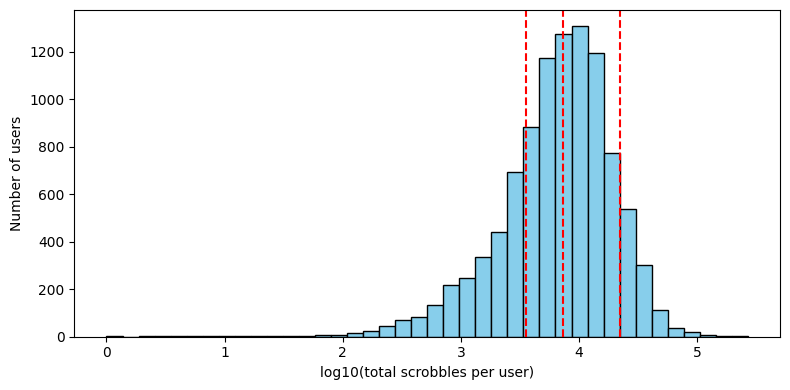

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(log_totals, bins=40, color="skyblue", edgecolor="k")
ax.set_xlabel("log10(total scrobbles per user)")
ax.set_ylabel("Number of users")
for q, label in [(q25, "reluctant"), (q50, "below_avg"), (q90, "active")]:
    ax.axvline(q, color="red", linestyle="--")
plt.tight_layout()
plt.show()


In [23]:
print("Group boundaries (raw scrobbles):")
print(f"reluctant ≤ {quantiles[0.25]:.0f}")
print(f"below_avg ≤ {quantiles[0.5]:.0f}")
print(f"active ≤ {quantiles[0.9]:.0f}")
print(f"power  > {quantiles[0.9]:.0f}")


Group boundaries (raw scrobbles):
reluctant ≤ 3584
below_avg ≤ 7292
active ≤ 22340
power  > 22340


# Stage 8 – How concentrated are different user groups on our artist clusters?

Now I want to join users with the artist clusters and measure, for each user, how their listening is distributed over the 10 KMeans clusters. For every user I’ll compute the share of their (top-artist) scrobbles in each cluster and then look at the maximum share per user—the “dominant cluster share”. Comparing this across activity groups will show whether reluctant users are mostly focused on one cluster while power users are more spread out, or vice versa.


In [24]:
# Attach cluster labels (0–9) to the artists used in the matrix
artists_clusters["artist_id"] = artists_matrix.index
scrobbles_top_clustered = scrobbles_top.merge(
    artists_clusters[["artist_id", "cluster"]], on="artist_id", how="inner"
)
scrobbles_top_clustered.head()


,user_id,artist_id,scrobbles,cluster
0,0,2,1659,5
1,0,7,612,0
2,0,17,380,2
3,0,16,377,2
4,0,8,252,9


In [25]:
# For each user, how much do they listen to each cluster? (as shares)
user_cluster = (
    scrobbles_top_clustered
    .groupby(["user_id", "cluster"])["scrobbles"].sum()
    .reset_index()
)
user_totals_top = user_cluster.groupby("user_id")["scrobbles"].sum().rename("user_total_top")
user_cluster = user_cluster.merge(user_totals_top, on="user_id")
user_cluster["cluster_share"] = user_cluster["scrobbles"] / user_cluster["user_total_top"]
user_cluster.head()


,user_id,cluster,scrobbles,user_total_top,cluster_share
0,0,0,1008,5355,0.188235
1,0,1,73,5355,0.013632
2,0,2,1437,5355,0.268347
3,0,3,84,5355,0.015686
4,0,4,354,5355,0.066106


In [26]:
# For each user, how dominant is their single biggest cluster?
user_conc = user_cluster.groupby("user_id")["cluster_share"].max().to_frame("max_cluster_share")
user_conc = user_conc.merge(user_activity["group"], left_index=True, right_index=True)
user_conc.groupby("group")["max_cluster_share"].describe()


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
active,3992.0,0.588436,0.173486,0.214458,0.451343,0.561002,0.710192,1.0
below_avg,2489.0,0.585479,0.178616,0.234414,0.442408,0.559714,0.712453,1.0
power,998.0,0.618291,0.176031,0.281953,0.476644,0.592639,0.741120,1.0
reluctant,2479.0,0.611123,0.187615,0.213147,0.461138,0.589618,0.742647,1.0


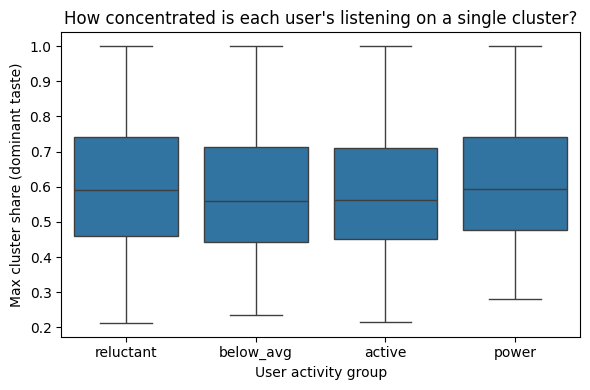

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=user_conc.reset_index(), x="group", y="max_cluster_share",
            order=["reluctant", "below_avg", "active", "power"], ax=ax)
ax.set_xlabel("User activity group")
ax.set_ylabel("Max cluster share (dominant taste)")
ax.set_title("How concentrated is each user's listening on a single cluster?")
plt.tight_layout()
plt.show()


# Stage 9 – Which clusters dominate for each activity group?

Now I want to see *which* of the 10 artist clusters each activity group leans toward. For every (user, cluster) pair I already have `cluster_share`. I’ll join in the activity group, then compute the average cluster_share for each (group, cluster). A heatmap of these averages will show, for example, whether power users over-index on certain clusters like K‑pop or metal compared to reluctant users.

In [28]:
# Average share of each cluster for each activity group
user_cluster_grouped = user_cluster.merge(
    user_activity["group"], left_on="user_id", right_index=True
)
group_cluster_share = (
    user_cluster_grouped
    .groupby(["group", "cluster"])["cluster_share"]
    .mean()
    .reset_index()
)
group_cluster_pivot = group_cluster_share.pivot(index="group", columns="cluster", values="cluster_share")
group_cluster_pivot


cluster,0,1,2,3,4,5,6,7,8,9
group,,,,,,,,,,
active,0.159504,0.184501,0.174701,0.164980,0.116490,0.154345,0.124038,0.133645,0.085621,0.315243
below_avg,0.158898,0.174368,0.191635,0.204403,0.153919,0.180461,0.164967,0.107641,0.093410,0.270028
power,0.164013,0.181055,0.162841,0.135437,0.170378,0.107197,0.086568,0.127814,0.074811,0.396220
reluctant,0.152809,0.166684,0.209859,0.222122,0.171682,0.200554,0.223363,0.088622,0.125451,0.264424


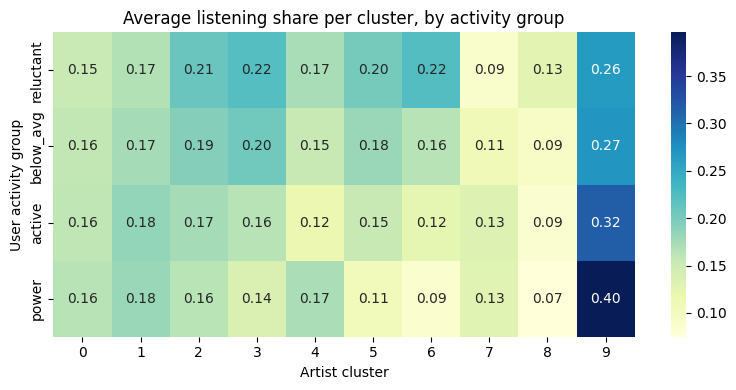

In [29]:
plt.figure(figsize=(8, 4))
sns.heatmap(group_cluster_pivot.loc[["reluctant","below_avg","active","power"]],
            annot=True, fmt=".2f", cmap="YlGnBu")
plt.xlabel("Artist cluster")
plt.ylabel("User activity group")
plt.title("Average listening share per cluster, by activity group")
plt.tight_layout()
plt.show()


# Stage 10 – Predict user activity group from cluster-share features

Now I want to treat this as a supervised classification problem. For each user, I already have the share of their listening in each of the 10 artist clusters, and I also have an activity label ("reluctant", "below_avg", "active", "power"). I’ll pivot the cluster_share table into a user × 10 feature matrix, join the activity labels, and train a simple multinomial logistic regression to see how well cluster preferences alone can predict activity level.


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Build feature matrix X and aligned target y
user_cluster_pivot = user_cluster.pivot_table(
    index="user_id", columns="cluster", values="cluster_share", fill_value=0
)
X = user_cluster_pivot.values
y = user_activity.loc[user_cluster_pivot.index, "group"].values


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf.fit(X_train, y_train)
print("Accuracy:", clf.score(X_test, y_test))
print(classification_report(y_test, clf.predict(X_test)))


Accuracy: 0.41214859437751006
              precision    recall  f1-score   support

      active       0.42      0.90      0.57       798
   below_avg       0.00      0.00      0.00       498
       power       0.00      0.00      0.00       200
   reluctant       0.36      0.21      0.27       496

    accuracy                           0.41      1992
   macro avg       0.20      0.28      0.21      1992
weighted avg       0.26      0.41      0.30      1992



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: 

# Stage 11 – Predict a user's dominant cluster from a small patch of listening

I’ll first define each user’s dominant taste as the cluster with the largest share over their full listening history (based on the top-artist subset). Then I’ll simulate seeing only 10% of each user’s scrobbles, recompute cluster shares from that tiny “early patch”, and try to predict the dominant cluster from these partial shares. This is like asking: with only a glimpse of what someone listens to, can I already guess which of the 10 clusters will dominate their overall taste?


In [32]:
# Dominant cluster label per user (full history)
user_dom = (
    user_cluster.sort_values(["user_id", "cluster_share"], ascending=[True, False])
    .drop_duplicates("user_id")[["user_id", "cluster"]]
    .set_index("user_id")["cluster"]
)
user_dom.value_counts(normalize=True)


cluster
9    0.310303
2    0.165194
5    0.139586
1    0.096405
3    0.092388
0    0.053826
6    0.044688
7    0.040470
4    0.031231
8    0.025909
Name: proportion, dtype: float64

In [33]:
# Simulate an "early patch": keep a random 10% of each (user, artist, cluster) scrobble count
import numpy as np

rng = np.random.default_rng(0)
scrobbles_early = scrobbles_top_clustered.copy()
scrobbles_early["early_scrobbles"] = rng.binomial(
    n=scrobbles_early["scrobbles"].astype(int),
    p=0.1
)
scrobbles_early = scrobbles_early[scrobbles_early["early_scrobbles"] > 0]
scrobbles_early.head()


,user_id,artist_id,scrobbles,cluster,early_scrobbles
0,0,2,1659,5,148
1,0,7,612,0,62
2,0,17,380,2,29
3,0,16,377,2,42
4,0,8,252,9,30


In [34]:
# Cluster shares from early patch
user_cluster_early = (
    scrobbles_early
    .groupby(["user_id", "cluster"])["early_scrobbles"].sum()
    .reset_index()
)
totals_early = (
    user_cluster_early.groupby("user_id")["early_scrobbles"]
    .sum().rename("user_total_early")
)
user_cluster_early = user_cluster_early.merge(totals_early, on="user_id")
user_cluster_early["cluster_share_early"] = (
    user_cluster_early["early_scrobbles"] / user_cluster_early["user_total_early"]
)
user_cluster_early.head()


,user_id,cluster,early_scrobbles,user_total_early,cluster_share_early
0,0,0,104,523,0.198853
1,0,1,13,523,0.024857
2,0,2,137,523,0.261950
3,0,3,5,523,0.009560
4,0,4,38,523,0.072658


In [35]:
# Pivot early cluster shares into features and align with dominant-cluster labels
X_early = user_cluster_early.pivot_table(
    index="user_id", columns="cluster", values="cluster_share_early", fill_value=0
)
common_users = X_early.index.intersection(user_dom.index)
X_early = X_early.loc[common_users].values
y_dom = user_dom.loc[common_users].values
X_early.shape, len(y_dom)


((9927, 10), 9927)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_early, y_dom, test_size=0.2, random_state=0, stratify=y_dom
)
clf2 = LogisticRegression(max_iter=1000)
clf2.fit(X_train, y_train)
print("Accuracy:", clf2.score(X_test, y_test))
print(classification_report(y_test, clf2.predict(X_test)))


Accuracy: 0.9516616314199395
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       106
           1       0.95      0.93      0.94       192
           2       0.94      0.98      0.96       328
           3       0.95      0.94      0.94       183
           4       0.97      0.90      0.93        62
           5       0.92      0.93      0.93       277
           6       0.95      0.93      0.94        89
           7       0.96      0.91      0.94        80
           8       1.00      0.96      0.98        51
           9       0.96      0.98      0.97       618

    accuracy                           0.95      1986
   macro avg       0.96      0.94      0.95      1986
weighted avg       0.95      0.95      0.95      1986



In [37]:
# For reference: majority-class baseline accuracy
majority = np.bincount(y_dom).argmax()
baseline = np.mean(y_test == majority)
print("Baseline (always predict cluster", majority, "):", baseline)


Baseline (always predict cluster 9 ): 0.311178247734139


# Stage 11b – How does the model get clusters right or wrong?

Since accuracy is very high, I want to see the confusion matrix to check where mistakes still happen. A confusion heatmap will show, for each true dominant cluster, which other clusters the model sometimes predicts instead. If the matrix is mostly diagonal with only a few off-diagonal spots, that means early listening almost uniquely determines the final taste scene.


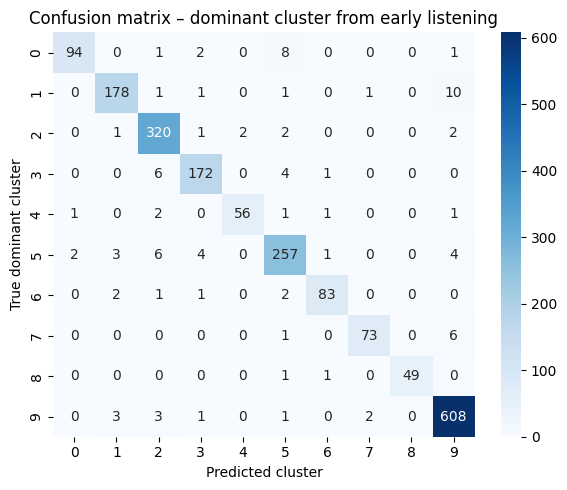

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = clf2.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=range(10))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted cluster")
plt.ylabel("True dominant cluster")
plt.title("Confusion matrix – dominant cluster from early listening")
plt.tight_layout()
plt.show()


In [39]:
# Per-cluster recall (how often we get each true cluster right)
recall_per_cluster = cm.diagonal() / cm.sum(axis=1)
pd.Series(recall_per_cluster, index=range(10), name="recall")


0    0.886792
1    0.927083
2    0.975610
3    0.939891
4    0.903226
5    0.927798
6    0.932584
7    0.912500
8    0.960784
9    0.983819
Name: recall, dtype: float64

# Stage 12 – Predict whether a user will listen to an artist

Now I want a supervised “match” model: given a user profile (their cluster shares) and an artist profile (its cluster), predict whether this user listens to that artist. I’ll build a dataset of positive pairs (user, artist actually listened) and negative pairs (random user–artist pairs that do not occur in the data). For each pair I will create features by concatenating the user’s 10 cluster shares and a one-hot vector of the artist’s cluster, then train a binary classifier to distinguish positives from negatives.


In [40]:
# Positive (user, artist) pairs from the clustered top-artist data
pos_pairs = scrobbles_top_clustered[["user_id", "artist_id"]].drop_duplicates()
pos_pairs["label"] = 1
# Subsample for speed if necessary
if len(pos_pairs) > 100_000:
    pos_pairs = pos_pairs.sample(100_000, random_state=0)
user_ids = pos_pairs["user_id"].unique()
artist_ids = artists_matrix.index.values
len(pos_pairs), len(user_ids), len(artist_ids)


(100000, 9740, 500)

In [41]:
# Negative pairs: random user–artist pairs that are not in positives
import numpy as np
rng = np.random.default_rng(0)
n_neg = len(pos_pairs)
neg_users = rng.choice(user_ids, size=n_neg, replace=True)
neg_artists = rng.choice(artist_ids, size=n_neg, replace=True)
neg_pairs = pd.DataFrame({"user_id": neg_users, "artist_id": neg_artists})
pos_set = set(map(tuple, pos_pairs[["user_id", "artist_id"]].to_numpy()))
neg_pairs = neg_pairs[~neg_pairs.apply(lambda r: (r.user_id, r.artist_id) in pos_set, axis=1)]
neg_pairs["label"] = 0
len(neg_pairs)


97987

In [42]:
# Build feature matrix: user cluster shares + artist cluster one-hot
pairs = pd.concat([pos_pairs, neg_pairs]).sample(frac=1, random_state=0).reset_index(drop=True)
artist_cluster_ohe = pd.get_dummies(
    artists_clusters.set_index("artist_id")["cluster"]
).reindex(artist_ids).fillna(0).astype(int)
X_user = user_cluster_pivot.loc[pairs["user_id"]].to_numpy()
X_artist = artist_cluster_ohe.loc[pairs["artist_id"]].to_numpy()
X = np.hstack([X_user, X_artist])
y = pairs["label"].to_numpy()
X.shape, y.mean()  # y.mean() is positive rate


((197987, 20), np.float64(0.5050836671094567))

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

clf3 = LogisticRegression(max_iter=1000)
clf3.fit(X_train, y_train)

y_pred = clf3.predict(X_test)
y_proba = clf3.predict_proba(X_test)[:, 1]

print("Accuracy:", clf3.score(X_test, y_test))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


Accuracy: 0.598035254305773
ROC AUC: 0.6583078681498112
              precision    recall  f1-score   support

           0       0.60      0.59      0.59     19598
           1       0.60      0.61      0.61     20000

    accuracy                           0.60     39598
   macro avg       0.60      0.60      0.60     39598
weighted avg       0.60      0.60      0.60     39598



In [44]:
# Quick sanity: how much better than random is this?
random_baseline = np.mean(y_test)  # accuracy of predicting all-1 or all-0 in a balanced set is ~0.5
print("Class balance (positive rate):", random_baseline)


Class balance (positive rate): 0.5050760139400979


# Stage 12b – Add user–artist cosine similarity as a richer feature

So far the match model only knew “which clusters a user likes” and “which cluster an artist is in”. Now I’ll build a true **user taste vector** by averaging the artist NMF components the user listens to (weighted by scrobbles), normalize it, and then compute the cosine similarity between this user vector and each artist’s NMF vector. I’ll add this similarity as an extra feature for the (user, artist) pairs and see whether the classifier improves.


In [45]:
from sklearn.preprocessing import normalize

# NMF vectors per artist, indexed by artist_id (already L2-normalized from the pipeline)
component_names = [f"component_{i}" for i in range(norm_features.shape[1])]
artist_nmf = pd.DataFrame(norm_features, index=artists_matrix.index, columns=component_names)

# Build user taste vectors: weighted average of artist NMF vectors by scrobbles
rows = []
for uid, g in scrobbles_top_clustered.groupby("user_id"):
    M = artist_nmf.loc[g["artist_id"]].values
    w = g["scrobbles"].values
    rows.append((uid, np.average(M, axis=0, weights=w)))
user_taste = pd.DataFrame(
    [v for _, v in rows],
    index=[uid for uid, _ in rows],
    columns=component_names,
)
user_taste[:] = normalize(user_taste.values)  # L2-normalize rows
user_taste.head()


,component_0,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8,component_9,component_10,component_11,component_12,component_13,component_14,component_15,component_16,component_17,component_18,component_19
0,0.012542,0.290453,0.579371,0.002070,0.630740,0.006462,0.125829,0.000208,0.175500,0.000076,0.005123,0.000000,0.001289,0.084184,0.037411,0.327969,0.002597,0.024113,0.002591,0.136473
1,0.487849,0.049102,0.180888,0.529635,0.020289,0.326931,0.002943,0.012363,0.051917,0.007701,0.041933,0.340495,0.447492,0.008162,0.005770,0.029806,0.078508,0.103718,0.011054,0.013081
2,0.039957,0.935500,0.136842,0.015391,0.009470,0.014623,0.003453,0.076382,0.067454,0.003475,0.102395,0.004096,0.010930,0.002039,0.080788,0.002266,0.003232,0.176876,0.212373,0.003640
3,0.377367,0.025390,0.007849,0.153203,0.001194,0.083014,0.000471,0.420972,0.002484,0.597270,0.100113,0.192552,0.343724,0.000366,0.003686,0.006912,0.194073,0.296968,0.037479,0.001820
5,0.004488,0.000000,0.614290,0.000000,0.391553,0.005893,0.068434,0.001454,0.006909,0.000000,0.000000,0.000000,0.003000,0.118147,0.347763,0.573835,0.000000,0.000000,0.000000,0.018794


In [46]:
# New feature: cosine similarity between user taste and artist NMF vector
user_vecs = user_taste.loc[pairs["user_id"]].to_numpy()
artist_vecs = artist_nmf.loc[pairs["artist_id"]].to_numpy()
sim = (user_vecs * artist_vecs).sum(axis=1)  # dot product = cosine similarity

X2 = np.hstack([X, sim.reshape(-1, 1)])

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=0, stratify=y
)
clf3b = LogisticRegression(max_iter=1000)
clf3b.fit(X2_train, y_train)
y_pred = clf3b.predict(X2_test)
y_proba = clf3b.predict_proba(X2_test)[:, 1]
print("Accuracy:", clf3b.score(X2_test, y_test))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))


Accuracy: 0.7717056416990757
ROC AUC: 0.8463188399326462
              precision    recall  f1-score   support

           0       0.77      0.77      0.77     19598
           1       0.78      0.77      0.77     20000

    accuracy                           0.77     39598
   macro avg       0.77      0.77      0.77     39598
weighted avg       0.77      0.77      0.77     39598

